In [21]:
### Knowledge involved
### 1) perform weighted linear regression (WLS) using 'sklearn' 
### 2) Basic visualization with matplotlib.pyplot
### Important note: Learn to check documentation of the package by yourself to learn new functions!
### e.g. for numpy: https://numpy.org/doc/stable/ 
###      for matplotlib: https://matplotlib.org/stable/api/index
###      for sklearn: https://scikit-learn.org/stable/api/index.html

In [22]:
### We aim to perform a 1D regression task with WLS method (iterative reweighting). 
###       Input data [1, 2, 3, 4, 5, 6, 7，8]
###       Output data [3.6, 4.8, 6.8, 7.4, 10.5, 9.6, 14.3, 11.8] 
###       The underlying true function is y = 2+1.5x
### We also assume that the Var(epsilon_i) is propotional to x_i

In [23]:
### Let's again construct the input and output vectors
import numpy as np
x = np.array([1,2,3,4,5,6,7,8])  ### Input as an array in numpy
y = np.array([3.6, 4.8, 6.8, 7.4, 10.5, 9.6, 14.3, 11.8])

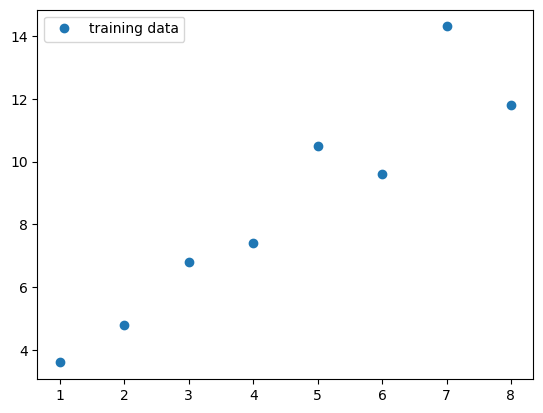

In [24]:
### Now lets visualize the data and see what it looks like
import matplotlib.pyplot as plt
plt.plot(x,y,'o',label='training data')
plt.legend()

### As you may observe, it looks quite heteroscedastic 
### And the noise seems to increase along x-axis (input)

In [25]:
### Now lets try to use WLS with iterative reweighting to address it
### As we did beofore, we need to reshape the input matrix to [8,1]
x = x.reshape(-1,1) 

In [26]:
### The iterative reweighting can be implemented as a 'for' loop
### Let's first define what is needed in this loop
d = np.ones(x.shape[0]) ### the initial guess of weights
### np.ones() generates an array of given size with all elements equal to 1
print('weights:',d)

weights: [1. 1. 1. 1. 1. 1. 1. 1.]


In [27]:
### Now lets start the iterative loop
### You can try to replace the 'for' loop with a 'while' loop by yourself
import sklearn as sk

### Define the maximum number of iteration
num_loop = 10

### Start the for loop with index i and 
### In each iteration, index i will increase by one
### i.e. from 'i=0' to 'i=num_loop-1' 
for i in range(num_loop):

    ### Define the linear model
    model = sk.linear_model.LinearRegression() 

    ### Same as we did for OLS, we use the same function LinearRegression()
    ### The only different here is that in the .fit() function, we will add an addtional term:
    ### sample_weight=d

    ### The sample_weight here represent the {d_i} in the lecture slides,
    ### In the first iteration, d = [1,...,1]
    ### Note that here the variable 'sample_weight' only takes in 1D vector
    model.fit(x,y,sample_weight=d)

    ### Compute the residual between data and model prediction
    r = y - model.predict(x)

    ### Compute 1\n sum r_i^2/x_i
    ### np.mean() function computes the mean value of a given vector.
    ### np.square() function helps us to do the square operation element-wisely 
    k = np.mean(np.square(r)/x)

    ### Update 'd_i' with 1/(kx_i)
    d_new = 1/(k*np.squeeze(x))
    print('In loop '+str(i)+': y = '+str(model.intercept_)+'+'+str(model.coef_[0])+'x')

    ### stopping criteria (whether the change of d is small enough)
    ### np.allclose(a,b,rtol=r_value,atol=a_value) returns True 
    ### if two arrays (a and b) are element-wise equal within a tolerance
    ### See documentation for more details:
    ###      https://numpy.org/doc/stable/reference/generated/numpy.allclose.html
    ### The if statement judges whether the loop is necessary to continue
    ### if not, we will stop the iteration.
    if np.allclose(d,d_new,rtol=1e-6,atol=1e-8):
        break

    d = d_new
    


In loop 0: y = 2.364285714285713+1.3857142857142863x
In loop 1: y = 2.176023638666103+1.4275503025186442x
In loop 2: y = 2.176023638666103+1.4275503025186436x


In [28]:
### Create test input points ranging from 0 to 9 with 200 points in between
### Dont forget to make into proper shape -> (200,1)
x_test = np.linspace(0,9,200).reshape(-1,1)
y_test= model.predict(x_test)

Ground truth: y = 2+1.5x
WLS estimates: y = 2.176023638666103+1.4275503025186436x


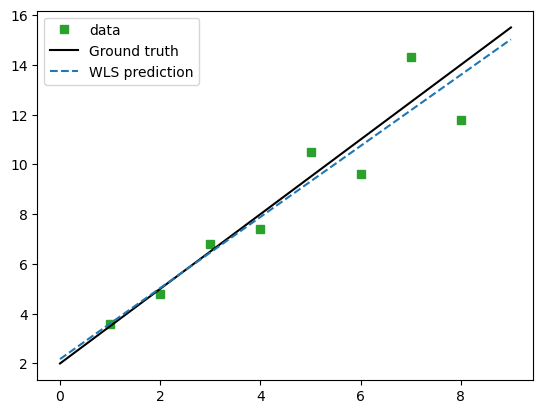

In [29]:
plt.plot(x,y,'s',color='tab:green',label='data') ### plot data
plt.plot(x_test,2+1.5*x_test,'-',color='black',label='Ground truth')
plt.plot(x_test,y_test,'--',color='tab:blue',label='WLS prediction')
plt.legend() ### show label

print('Ground truth: y = 2+1.5x')
print('WLS estimates: y = '+str(model.intercept_)+'+'+str(model.coef_[0])+'x')